#### Simple EDA on alerts_csv/*.txt files

In [4]:
import pandas as pd
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from itertools import combinations
from collections import Counter

In [5]:
root = Path.cwd().parent.parent
sys.path.insert(0, str(root / "thesis"))

In [32]:
scenario = "harrison"

In [34]:
file_path = f'/Users/annavisman/stack/TUDelft/thesis/msc-thesis/data/alerts_csv/{scenario}_alerts.txt'

# Load the file into a DataFrame
df = pd.read_csv(file_path)

print(f"Label distribution for scenario {scenario}:")
print(df["time_label"].value_counts())

Label distribution for scenario harrison:
time_label
dirb                    416011
false_positive          162456
wpscan                    9709
dnsteal                   3239
cracking                  1256
service_scans              829
network_scans              296
privilege_escalation        94
webshell                    32
reverse_shell               20
service_stop                 6
Name: count, dtype: int64


In [38]:
df["time_norm"] = pd.to_datetime(df["time"], unit="s", utc=True, errors="coerce")
df.head()

,time,name,ip,host,short,time_label,event_label,time_norm
0,1643932807,Suricata: Alert - ET INFO Observed DNS Query t...,192.168.131.109,internal_share,S-Dns-Qry3,false_positive,dnsteal,2022-02-04 00:00:07+00:00
1,1643932807,Wazuh: First time this IDS alert is generated.,192.168.131.109,internal_share,W-All-Ids,false_positive,-,2022-02-04 00:00:07+00:00
2,1643932807,Wazuh: First time this IDS alert is generated.,192.168.128.1,inet-firewall,W-All-Ids,false_positive,-,2022-02-04 00:00:07+00:00
3,1643932807,Suricata: Alert - ET INFO Observed DNS Query t...,192.168.128.1,inet-firewall,S-Dns-Qry3,false_positive,dnsteal,2022-02-04 00:00:07+00:00
4,1643932819,Suricata: Alert - ET INFO Observed DNS Query t...,192.168.131.109,internal_share,S-Dns-Qry3,false_positive,dnsteal,2022-02-04 00:00:19+00:00


##### 1) Create time windows of 2 seconds

In [39]:
def build_labeled_window_transactions(
    df: pd.DataFrame,
    time_col: str = "time_norm",
    detector_col: str = "short",
    host_col: str = "host",
    label_col: str = "time_label",
    benign_label: str = "false_positive",
    window_size_s: int = 2,
):
    out = df.copy()

    # Clean
    needed = [time_col, detector_col, host_col, label_col]
    out = out.dropna(subset=needed).copy()
    out[time_col] = pd.to_numeric(out[time_col], errors="coerce")
    out = out.dropna(subset=[time_col]).copy()
    out[time_col] = out[time_col].astype("int64")

    # Window assignment
    out["window_start"] = (out[time_col] // window_size_s) * window_size_s
    out["window_end"] = out["window_start"] + window_size_s

    # Flat items
    out["detector_item"] = out[detector_col].astype(str)
    out["host_item"] = out[host_col].astype(str)

    def _label_window(labels: pd.Series) -> str:
        labels = set(labels.astype(str))
        has_benign = benign_label in labels
        has_attack = any(lbl != benign_label for lbl in labels)

        if has_attack and has_benign:
            return "mixed"
        elif has_attack:
            return "attack"
        else:
            return "benign"

    tx = (
        out.groupby(["window_start", "window_end"], sort=True)
        .apply(
            lambda g: pd.Series({
                "n_alerts": len(g),
                "items": set(g["detector_item"]).union(set(g["host_item"])),
                "alert_labels": set(g[label_col].astype(str)),
                "tx_label": _label_window(g[label_col]),
            })
        )
        .reset_index()
    )

    return tx

##### 2) Represent each alert as items

In [43]:
transactions = build_labeled_window_transactions(
    df,
    time_col="time_norm",
    window_size_s=2,
)

/var/folders/69/6nn2sm8d7qq0p98t_qgp1ckr0000gn/T/ipykernel_61257/1807281708.py:41: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


##### 3) Split data using the labels

In [42]:
benign_transactions = transactions[transactions["tx_label"] == "benign"].copy()
attack_transactions = transactions[transactions["tx_label"] == "attack"].copy()
mixed_transactions  = transactions[transactions["tx_label"] == "mixed"].copy()
print(transactions["tx_label"].value_counts())

tx_label
benign    34562
attack     2586
Name: count, dtype: int64


In [44]:
print(benign_transactions[["window_start", "n_alerts", "items"]].head())
print(attack_transactions[["window_start", "n_alerts", "items"]].head())

          window_start  n_alerts  \
0  1643932801000000000         8   
1  1643932803000000000         5   
2  1643932807000000000        13   
3  1643932810000000000         1   
4  1643932819000000000         5   

                                               items  
0  {A-Aud-Com6, A-All-Evt, A-Aud-Com2, A-Aud-Com3...  
1   {A-Aud-Com2, A-Aud-Com6, cloud_share, A-All-Evt}  
2  {A-Dns-Val1, A-All-Evt, A-Dns-Ent, internal_sh...  
3                        {A-Dns-Val1, inet-firewall}  
4  {A-Dns-Chr, internal_share, W-All-Evt, inet-dn...  
              window_start  n_alerts  \
32750  1644303900000000000        11   
32751  1644303901000000000         3   
32752  1644303922000000000         4   
32753  1644303930000000000         3   
32754  1644303946000000000         4   

                                                   items  
32750  {mail, W-Sys-Dov, webserver, W-All-Evt, S-Tls-...  
32751                                  {mail, W-Sys-Dov}  
32752  {S-Dns-Qry3, internal_share,

##### 4) Measure co-occurrence strength

##### Transaction size

In [ ]:
tx = transactions.copy()

tx["tx_size"] = tx["items"].apply(len)

# Summary stats per class
size_summary = tx.groupby("tx_label")["tx_size"].describe()
print(size_summary)

size_counts = (
    tx.groupby(["tx_label", "tx_size"])
      .size()
      .reset_index(name="count")
      .sort_values(["tx_label", "tx_size"])
)

            count      mean       std  min  25%  50%  75%   max
tx_label                                                       
attack     2586.0  3.855762  1.867486  2.0  3.0  4.0  4.0  15.0
benign    34562.0  3.667756  1.106701  2.0  2.0  4.0  4.0  10.0


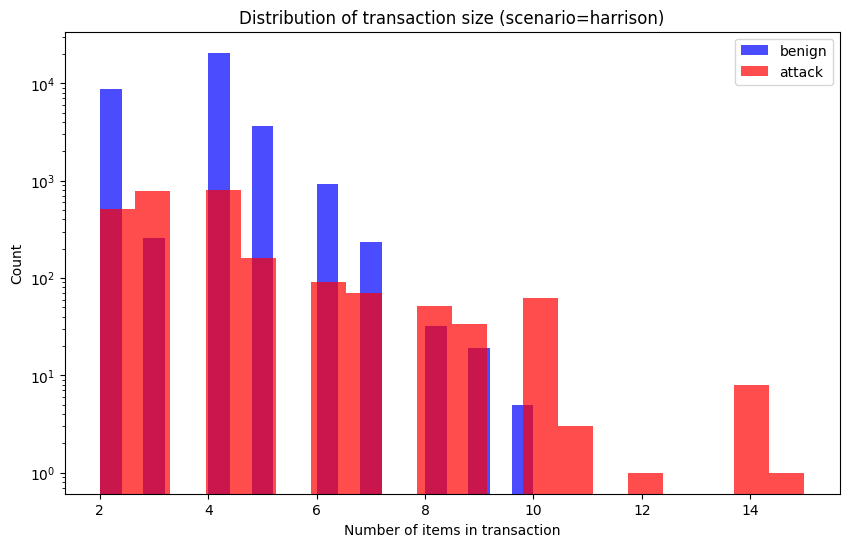

In [46]:
plt.figure(figsize=(10, 6))

colors = {"benign": "blue", "attack": "red"}

for label in ["benign", "attack"]:
    subset = tx.loc[tx["tx_label"] == label, "tx_size"]
    plt.hist(subset, bins=20, alpha=0.7, color=colors[label], label=label)

plt.title(f"Distribution of transaction size (scenario={scenario})")
plt.xlabel("Number of items in transaction")
plt.ylabel("Count")
plt.yscale("log")
plt.legend()
plt.show()

##### Pair frequency

In [48]:
def count_pair_frequency(df: pd.DataFrame, items_col: str = "items") -> pd.DataFrame:
    pair_counter = Counter()

    for items in df[items_col]:
        items = sorted(set(items))
        for pair in combinations(items, 2):
            pair_counter[pair] += 1

    out = pd.DataFrame(
        [{"pair": pair, "pair_count": count} for pair, count in pair_counter.items()]
    ).sort_values("pair_count", ascending=False)

    return out.reset_index(drop=True)

In [ ]:
pair_freq_all = count_pair_frequency(tx)
print(pair_freq_all.head(20))

                               pair  pair_count
0        (W-All-Evt, inet-firewall)       24645
1           (S-Dns-Qry3, W-All-Evt)       23591
2       (W-All-Evt, internal_share)       23582
3      (S-Dns-Qry3, internal_share)       23560
4       (S-Dns-Qry3, inet-firewall)       23560
5   (inet-firewall, internal_share)       23549
6           (W-Sys-Dov, smith_mail)        3852
7                 (W-Sys-Dov, mail)        3745
8           (W-All-Evt, W-All-Mul1)        3248
9       (W-All-Mul1, inet-firewall)        3224
10     (W-All-Mul1, internal_share)        3110
11         (S-Dns-Qry3, W-All-Mul1)        3109
12           (S-Tls-Rec, W-All-Evt)        2498
13           (S-Tls-Hnd, S-Tls-Rec)        2497
14           (S-Tls-Hnd, W-All-Evt)        2496
15         (W-Sys-Dov, taylor_mail)        1790
16     (W-Acc-400, intranet_server)        1617
17          (W-Acc-400, W-All-Mul3)        1612
18    (W-All-Mul3, intranet_server)        1612
19           (W-All-Evt, webserver)     

In [50]:
pair_freq_benign = count_pair_frequency(benign_transactions)
print(pair_freq_benign.head(20))

                               pair  pair_count
0        (W-All-Evt, inet-firewall)       24188
1           (S-Dns-Qry3, W-All-Evt)       23239
2       (W-All-Evt, internal_share)       23230
3      (S-Dns-Qry3, internal_share)       23208
4       (S-Dns-Qry3, inet-firewall)       23208
5   (inet-firewall, internal_share)       23197
6           (W-Sys-Dov, smith_mail)        3703
7                 (W-Sys-Dov, mail)        3468
8           (W-All-Evt, W-All-Mul1)        3200
9       (W-All-Mul1, inet-firewall)        3177
10     (W-All-Mul1, internal_share)        3077
11         (S-Dns-Qry3, W-All-Mul1)        3076
12           (S-Tls-Hnd, S-Tls-Rec)        2293
13           (S-Tls-Hnd, W-All-Evt)        2292
14           (S-Tls-Rec, W-All-Evt)        2292
15         (W-Sys-Dov, taylor_mail)        1639
16           (W-All-Evt, webserver)        1262
17           (S-Tls-Hnd, webserver)        1255
18           (S-Tls-Rec, webserver)        1255
19       (S-Tls-Hnd, inet-firewall)     

In [19]:
pair_freq_attack= count_pair_frequency(attack_transactions)
print(pair_freq_attack.head(20))

                               pair  pair_count
0      (W-Acc-400, intranet_server)        1617
1     (W-All-Mul3, intranet_server)        1612
2           (W-Acc-400, W-All-Mul3)        1612
3      (A-All-Evt, intranet_server)         463
4            (A-All-Evt, W-Acc-400)         459
5        (W-All-Evt, inet-firewall)         457
6           (A-All-Evt, W-All-Mul3)         453
7       (W-All-Evt, internal_share)         352
8           (S-Dns-Qry3, W-All-Evt)         352
9       (S-Dns-Qry3, inet-firewall)         352
10  (inet-firewall, internal_share)         352
11     (S-Dns-Qry3, internal_share)         352
12                (W-Sys-Dov, mail)         277
13         (A-Acc-Chr2, W-All-Mul3)         224
14          (A-Acc-Chr2, W-Acc-400)         224
15    (A-Acc-Chr2, intranet_server)         224
16           (S-Tls-Rec, W-All-Evt)         206
17           (S-Tls-Hnd, S-Tls-Rec)         204
18           (S-Tls-Hnd, W-All-Evt)         204
19           (W-Acc-400, W-Acc-Sus)     

In [24]:
intersection = pd.merge(
    pair_freq_benign.rename(columns={"pair_count": "benign_count"}),
    pair_freq_attack.rename(columns={"pair_count": "attack_count"}),
    on="pair",
    how="inner",
).fillna(0)

In [25]:
intersection.head(20)

,pair,benign_count,attack_count
0,"(W-All-Evt, inet-firewall)",24188,457
1,"(S-Dns-Qry3, W-All-Evt)",23239,352
2,"(W-All-Evt, internal_share)",23230,352
3,"(S-Dns-Qry3, internal_share)",23208,352
4,"(S-Dns-Qry3, inet-firewall)",23208,352
5,"(inet-firewall, internal_share)",23197,352
6,"(W-Sys-Dov, smith_mail)",3703,149
7,"(W-Sys-Dov, mail)",3468,277
8,"(W-All-Evt, W-All-Mul1)",3200,48
9,"(W-All-Mul1, inet-firewall)",3177,47


In [ ]:
# compare the total number of pairs existing with the number of pairs that exist in both classes
total_pairs = len(pair_freq_all)
intersection_pairs = len(intersection)
print(f"Total unique pairs: {total_pairs}")
print(f"Pairs in both classes: {intersection_pairs}")
print(f"Percentage of pairs in both classes: {intersection_pairs / total_pairs:.2%}")

Total unique pairs: 767
Pairs in both classes: 172


ValueError: Invalid format specifier '.2%sep=s' for object of type 'float'

In [26]:
pair_compare = (
    pair_freq_attack.rename(columns={"pair_count": "attack_count"})
    .merge(
        pair_freq_benign.rename(columns={"pair_count": "benign_count"}),
        on="pair",
        how="outer"
    )
    .fillna(0)
)

pair_compare["attack_count"] = pair_compare["attack_count"].astype(int)
pair_compare["benign_count"] = pair_compare["benign_count"].astype(int)
pair_compare["total_count"] = pair_compare["attack_count"] + pair_compare["benign_count"]

pair_compare = pair_compare.sort_values(
    ["attack_count", "total_count"], ascending=False
).reset_index(drop=True)

print(pair_compare.head(30))

                               pair  attack_count  benign_count  total_count
0      (W-Acc-400, intranet_server)          1617             0         1617
1           (W-Acc-400, W-All-Mul3)          1612             0         1612
2     (W-All-Mul3, intranet_server)          1612             0         1612
3      (A-All-Evt, intranet_server)           463             1          464
4            (A-All-Evt, W-Acc-400)           459             0          459
5        (W-All-Evt, inet-firewall)           457         24188        24645
6           (A-All-Evt, W-All-Mul3)           453             0          453
7           (S-Dns-Qry3, W-All-Evt)           352         23239        23591
8       (W-All-Evt, internal_share)           352         23230        23582
9       (S-Dns-Qry3, inet-firewall)           352         23208        23560
10     (S-Dns-Qry3, internal_share)           352         23208        23560
11  (inet-firewall, internal_share)           352         23197        23549

##### Pattern consistency

In [ ]:
# def support(df: pd.DataFrame, pattern: set, items_col: str = "items") -> float:
#     if len(df) == 0:
#         return 0.0
#     return df[items_col].apply(lambda items: pattern.issubset(items)).mean()


# def pattern_metrics(
#     tx: pd.DataFrame,
#     pattern: set,
#     items_col: str = "items",
#     label_col: str = "tx_label"
# ) -> dict:
#     attack_df = tx[tx[label_col] == "attack"]
#     benign_df = tx[tx[label_col] == "benign"]

#     supp_attack = support(attack_df, pattern, items_col)
#     supp_benign = support(benign_df, pattern, items_col)

#     denom = supp_attack + supp_benign
#     conf_attack = supp_attack / denom if denom > 0 else 0.0
#     conf_benign = supp_benign / denom if denom > 0 else 0.0

#     return {
#         "pattern": tuple(sorted(pattern)),
#         "support_attack": supp_attack,
#         "support_benign": supp_benign,
#         "confidence_attack": conf_attack,
#         "confidence_benign": conf_benign,
#     }

In [28]:
def all_pair_metrics(
    tx: pd.DataFrame,
    items_col: str = "items",
    label_col: str = "tx_label",
    min_total_count: int = 1
) -> pd.DataFrame:
    attack_df = tx[tx[label_col] == "attack"]
    benign_df = tx[tx[label_col] == "benign"]

    # Count pairs in each class
    attack_pairs = count_pair_frequency(attack_df, items_col).rename(columns={"pair_count": "attack_count"})
    benign_pairs = count_pair_frequency(benign_df, items_col).rename(columns={"pair_count": "benign_count"})

    pair_df = (
        attack_pairs.merge(benign_pairs, on="pair", how="outer")
        .fillna(0)
    )

    pair_df["attack_count"] = pair_df["attack_count"].astype(int)
    pair_df["benign_count"] = pair_df["benign_count"].astype(int)
    pair_df["total_count"] = pair_df["attack_count"] + pair_df["benign_count"]

    n_attack = len(attack_df)
    n_benign = len(benign_df)

    pair_df["support_attack"] = pair_df["attack_count"] / n_attack if n_attack else 0.0
    pair_df["support_benign"] = pair_df["benign_count"] / n_benign if n_benign else 0.0

    denom = pair_df["support_attack"] + pair_df["support_benign"]
    pair_df["confidence_attack"] = pair_df["support_attack"] / denom.replace(0, pd.NA)
    pair_df["confidence_benign"] = pair_df["support_benign"] / denom.replace(0, pd.NA)

    pair_df["confidence_attack"] = pair_df["confidence_attack"].fillna(0.0)
    pair_df["confidence_benign"] = pair_df["confidence_benign"].fillna(0.0)

    pair_df = pair_df[pair_df["total_count"] >= min_total_count].copy()

    return pair_df.sort_values(
        ["confidence_attack", "support_attack", "total_count"],
        ascending=False
    ).reset_index(drop=True)

In [29]:
pair_metrics_df = all_pair_metrics(tx)
print(pair_metrics_df.head(30))

                             pair  attack_count  benign_count  total_count  \
0    (W-Acc-400, intranet_server)          1617             0         1617   
1         (W-Acc-400, W-All-Mul3)          1612             0         1612   
2   (W-All-Mul3, intranet_server)          1612             0         1612   
3          (A-All-Evt, W-Acc-400)           459             0          459   
4         (A-All-Evt, W-All-Mul3)           453             0          453   
5         (A-Acc-Chr2, W-Acc-400)           224             0          224   
6        (A-Acc-Chr2, W-All-Mul3)           224             0          224   
7          (W-Acc-400, W-Acc-Sus)           189             0          189   
8         (W-Acc-Sus, W-All-Mul3)           189             0          189   
9    (W-Acc-Sus, intranet_server)           189             0          189   
10         (W-Acc-400, W-Acc-Att)           184             0          184   
11        (W-Acc-Att, W-All-Mul3)           184             0   

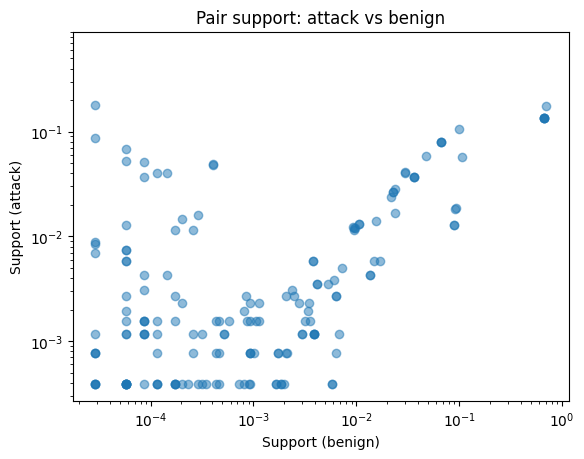

In [31]:
df = pair_metrics_df.copy()

plt.figure()

plt.scatter(
    df["support_benign"],
    df["support_attack"],
    alpha=0.5
)

plt.yscale("log")
plt.xscale("log")
plt.xlabel("Support (benign)")
plt.ylabel("Support (attack)")
plt.title("Pair support: attack vs benign")

plt.show()